In [48]:
import sys
sys.path.insert(0, '../../')
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from deepssfp import ssfp, recon

def generate_training_data_pts(num_samples=100, num_pcs=4):
    T1 = np.random.uniform(0.5, 2.0, num_samples)
    T2 = np.random.uniform(0.01, 0.1, num_samples)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, 2 * np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []

    for i in range(num_samples):
        M_2pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        X.append(M_2pc)
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        y.append(np.sqrt(np.mean(np.abs(M_4pc)**2)))
    
    return np.array(X), np.array(y)

def generate_training_data_1d(num_samples=100, num_pcs=4, width = 128):
    T1 = np.random.uniform(0.5, 2.0, num_samples)
    T2 = np.random.uniform(0.01, 0.1, num_samples)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, width)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, 2 * np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_2pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f)
        X.append(M_2pc)
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
        y.append(np.sqrt(np.mean(np.abs(M_4pc)**2)))
    
    return np.array(X), np.array(y)

def generate_training_data_2d():
    pass

(100, 4)


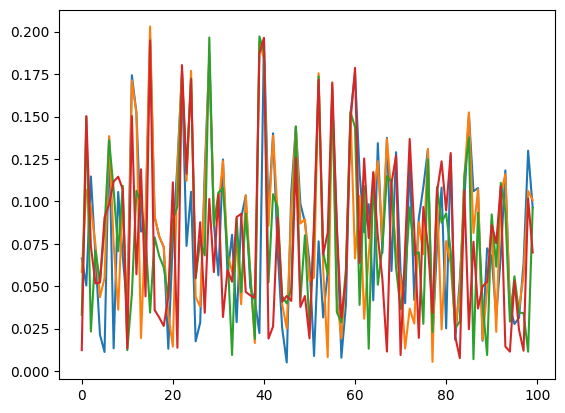

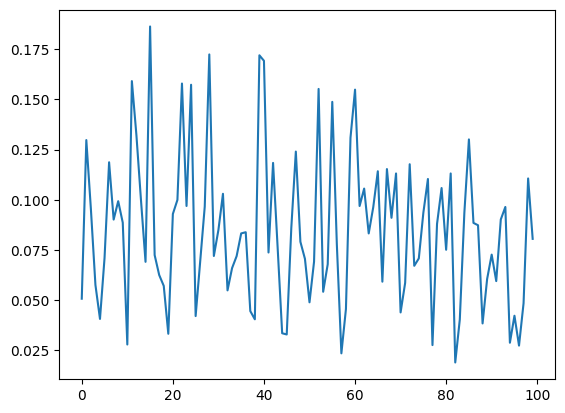

In [9]:
x, y = generate_training_data_pts()

print(x.shape)
plt.plot(np.abs(x))
plt.show()

plt.plot(np.abs(y))
plt.show()

(1, 128, 4)


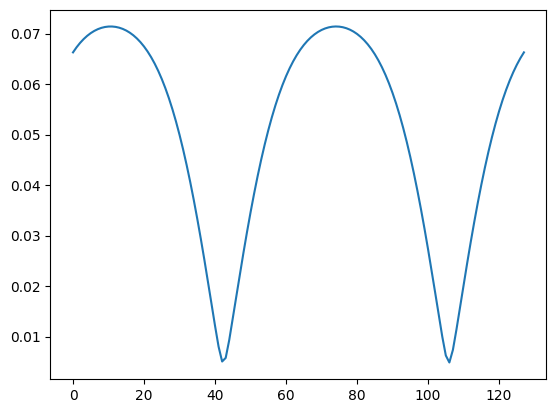

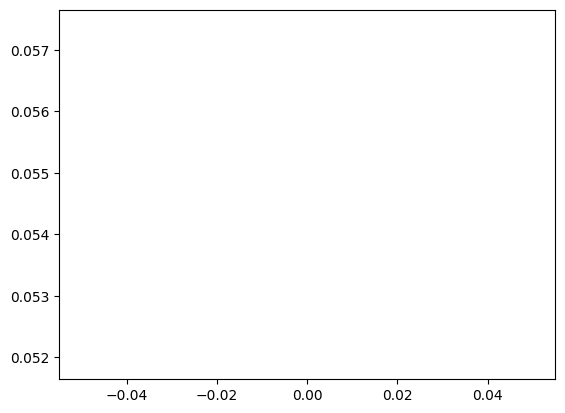

In [53]:
x, y = generate_training_data_1d()

print(x.shape)
plt.plot(np.abs(x[0,:,1]))
plt.show()

plt.plot(np.abs(y))
plt.show()

In [ ]:
N = 128
T1, T2 = 1.2 * np.ones((N, N)), .035 * np.ones((N, N))
TR, alpha = 5e-3, np.deg2rad(30)
TE = TR / 2.0
BetaMax = 2 * np.pi
beta = np.linspace(-BetaMax, BetaMax, N)
f = beta / TR / (2 * np.pi)
f = np.tile(f, (N, 1))
npcs = 4
pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)

start_time = time.time()
M2 = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, field_map=f)
print('Time elapsed:', time.time() - start_time)
print(M2.shape)

plt.imshow(abs(M2[:,:,1]))
plt.show()